# Data Discovery Dataset MMEW

## Peta proyek (baca dulu sebelum sidang)

Workspace aktif ada di `python test/`. Setiap arsitektur **diisolasi** di foldernya sendiri agar checkpoint `.pth` dan notebook tidak tercampur.

```text
python test/
├── discovery/          # EDA saja — tidak ada training
│   ├── smic_data_discovery.ipynb
│   └── mmew_data_discovery.ipynb
├── stgcn/              # model graf Face Mesh (468 node)
│   ├── stgcn_mmew_extraction.ipynb
│   ├── stgcn_mmew_pretraining.ipynb
│   ├── stgcn_smic_extraction.ipynb
│   ├── stgcn_smic_training.ipynb   # LOSO + transfer MMEW
│   ├── stgcn_mmew_pretrained.pth
│   ├── stgcn_best_model.pth
│   └── stgcn_mmew_landmarks/       # 300 file .npy MMEW
├── r3d18/              # 3D-CNN R3D-18 pada klip video
│   ├── r3d18_smic_pipeline.ipynb
│   └── r3d18_best_model.pth
├── vit/                # ViT pada gambar Optical Flow
│   ├── vit_optical_flow_pipeline.ipynb
│   └── vit_best_model.pth
├── dataset/            # data mentah + hasil ekstraksi bersama
│   ├── SMIC_all_cropped/           # frame BMP ter-crop & registrasi
│   ├── MMEW/                       # JPG mikro (sekuens) + makro (still)
│   ├── stgcn_smic_landmarks/       # .npy graf SMIC
│   └── vit_optical_flow_frames/    # JPG flow untuk ImageFolder
└── requirements.txt
```

**Alur skripsi yang benar:** discovery → ekstraksi fitur → (opsional pre-train) → LOSO SMIC. Ketiga model dievaluasi dengan protokol **LOSO** yang sama agar perbandingan adil (tanpa Subject Leakage dari split 80/20).

**Letak di peta:** `discovery/` membaca `../dataset/MMEW/`. Temuan kuncinya: hanya `Micro_Expression` yang punya sumbu waktu, jadi hanya itu yang dipakai pre-training ST-GCN.

Notebook ini memindai folder `MMEW` (Micro-and Macro-Expression Warehouse) **sebelum** pra-pemrosesan. Tujuannya memahami struktur asli, format file, resolusi, dan distribusi kelas.

> Hanya **Data Discovery / EDA**. Tidak ada ekstraksi landmark MediaPipe, DataLoader, atau training.


In [1]:
# =============================================================================
# 1. IMPORT LIBRARY DAN KONFIGURASI PATH
# =============================================================================
import random
import re
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Path relatif terhadap folder discovery/ (naik satu tingkat ke python test/).
# Naik dari discovery/ ke python test/, lalu masuk dataset/MMEW.
# Alasan: MMEW dipindahkan ke dataset/ agar semua data mentah satu atap.
DATASET_ROOT = Path('../dataset/MMEW').resolve()
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv', '.wmv'}

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder MMEW tidak ditemukan: {DATASET_ROOT}\n'
        'Sesuaikan DATASET_ROOT dengan lokasi dataset Anda.'
    )

print(f'Root dataset : {DATASET_ROOT}')
print(f'Isi level 1  : {sorted(p.name for p in DATASET_ROOT.iterdir() if not p.name.startswith("."))}')


Root dataset : /Users/stefanieagahari/Micro-Expression-Detector/python test/MMEW
Isi level 1  : ['Macro_Expression', 'Micro_Expression']


## 2. Hierarki Folder dan Jumlah Sampel

Cell berikut menelusuri `MMEW` dan mencetak skema folder. Satu **sampel mikro** = satu folder sekuens (`S01-01-001/`). Satu **sampel makro** = satu berkas `.jpg` di dalam folder emosi subjek.
**Baca hierarki dengan cermat.** Mikro: `emosi → klip → frame`. Makro: `subjek → emosi → satu JPG`. ST-GCN **tidak bisa** dilatih pada makro tanpa membuat sekuens palsu.


In [2]:
# =============================================================================
# 2. PEMINDAIAN STRUKTUR DIREKTORI
# =============================================================================
def list_visible(path: Path):
    """Anak folder/file tanpa item tersembunyi (.DS_Store, dll)."""
    return sorted(
        [p for p in path.iterdir() if not p.name.startswith('.')],
        key=lambda p: (not p.is_dir(), p.name.lower()),
    )


def print_tree(path: Path, prefix: str = '', max_children: int = 4, depth: int = 0, max_depth: int = 3):
    """Cetak hierarki ringkas; anak berlebih disingkat agar laporan tetap terbaca."""
    children = list_visible(path)
    shown = children[:max_children]
    hidden = len(children) - len(shown)

    for i, child in enumerate(shown):
        is_last = (i == len(shown) - 1) and hidden == 0
        branch = '└── ' if is_last else '├── '
        suffix = '/' if child.is_dir() else ''
        extra = ''
        if child.is_dir():
            n_inner = len(list_visible(child))
            extra = f'  ({n_inner} item)'
        print(f'{prefix}{branch}{child.name}{suffix}{extra}')
        if child.is_dir() and depth < max_depth:
            extension = '    ' if is_last else '│   '
            print_tree(child, prefix + extension, max_children, depth + 1, max_depth)

    if hidden > 0:
        print(f'{prefix}└── ... (+{hidden} item lain)')


print('=' * 80)
print('HIERARKI FOLDER MMEW (disingkat)')
print('=' * 80)
print(f'{DATASET_ROOT.name}/')
print_tree(DATASET_ROOT, max_children=6, max_depth=2)

micro_root = DATASET_ROOT / 'Micro_Expression'
macro_root = DATASET_ROOT / 'Macro_Expression'

print('\n' + '=' * 80)
print('POLA ORGANISASI')
print('=' * 80)
print('Micro_Expression : emosi → folder sekuens (Sxx-yy-zzz) → frame .jpg')
print('Macro_Expression : subjek (S01..S30) → emosi → berkas .jpg tunggal')
print()
print('# Komentar analisis: kedua partisi memakai skema yang BERBEDA.')
print('# Mikro cocok untuk ST-GCN (ada sumbu waktu). Makro hanya still image.')

HIERARKI FOLDER MMEW (disingkat)
MMEW/
├── Macro_Expression/  (30 item)
│   ├── S01/  (6 item)
│   │   ├── anger/  (5 item)
│   │   ├── disgust/  (5 item)
│   │   ├── fear/  (5 item)
│   │   ├── happiness/  (5 item)
│   │   ├── sadness/  (5 item)
│   │   └── surprise/  (5 item)
│   ├── S02/  (6 item)
│   │   ├── anger/  (5 item)
│   │   ├── disgust/  (5 item)
│   │   ├── fear/  (5 item)
│   │   ├── happiness/  (5 item)
│   │   ├── sadness/  (5 item)
│   │   └── surprise/  (5 item)
│   ├── S03/  (6 item)
│   │   ├── anger/  (5 item)
│   │   ├── disgust/  (5 item)
│   │   ├── fear/  (5 item)
│   │   ├── happiness/  (5 item)
│   │   ├── sadness/  (5 item)
│   │   └── surprise/  (5 item)
│   ├── S04/  (6 item)
│   │   ├── anger/  (5 item)
│   │   ├── disgust/  (5 item)
│   │   ├── fear/  (5 item)
│   │   ├── happiness/  (5 item)
│   │   ├── sadness/  (5 item)
│   │   └── surprise/  (5 item)
│   ├── S05/  (6 item)
│   │   ├── anger/  (5 item)
│   │   ├── disgust/  (5 item)
│   │   ├── fear/

## 3. Identifikasi Format File

Deteksi ekstensi dominan (video vs urutan gambar) dan hitung jumlah frame per klip mikro.
**Mengapa rata-rata frame penting?** ST-GCN memaksa `T=16`. Jika klip rata-rata 38 frame, `np.linspace` akan men-subsample merata dari onset sampai offset.


In [3]:
# =============================================================================
# 3. IDENTIFIKASI FORMAT FILE DAN INDEKS SAMPEL
# =============================================================================
CLIP_NAME_RE = re.compile(r'^(?P<subject>S\d{2})-(?P<code>\d{2})-(?P<seq>\d{3})$', re.IGNORECASE)


def collect_extensions(root: Path) -> Counter:
    counts = Counter()
    for path in root.rglob('*'):
        if path.is_file() and not path.name.startswith('.'):
            counts[path.suffix.lower() or '<tanpa ekstensi>'] += 1
    return counts


def parse_clip_id(name: str) -> dict:
    match = CLIP_NAME_RE.match(name)
    if not match:
        return {'subject_id': None, 'emotion_code': None, 'sequence_no': None}
    return {
        'subject_id': match.group('subject').upper(),
        'emotion_code': match.group('code'),
        'sequence_no': match.group('seq'),
    }


def discover_micro_clips(micro_root: Path) -> pd.DataFrame:
    """Satu baris = satu folder sekuens mikro (satu sampel temporal)."""
    records = []
    if not micro_root.is_dir():
        return pd.DataFrame()

    for emotion_dir in list_visible(micro_root):
        if not emotion_dir.is_dir():
            continue
        for clip_dir in list_visible(emotion_dir):
            if not clip_dir.is_dir():
                continue
            frames = [
                p for p in list_visible(clip_dir)
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            ]
            identity = parse_clip_id(clip_dir.name)
            records.append({
                'partition': 'Micro_Expression',
                'sample_kind': 'frame_sequence',
                'emotion_label': emotion_dir.name,
                'clip_id': clip_dir.name,
                'n_frames': len(frames),
                'sample_path': str(clip_dir.resolve()),
                **identity,
            })
    return pd.DataFrame(records)


def discover_macro_stills(macro_root: Path) -> pd.DataFrame:
    """Satu baris = satu gambar makro (bukan sekuens)."""
    records = []
    if not macro_root.is_dir():
        return pd.DataFrame()

    for subject_dir in list_visible(macro_root):
        if not subject_dir.is_dir():
            continue
        for emotion_dir in list_visible(subject_dir):
            if not emotion_dir.is_dir():
                continue
            for image_path in list_visible(emotion_dir):
                if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue
                identity = parse_clip_id(image_path.stem)
                records.append({
                    'partition': 'Macro_Expression',
                    'sample_kind': 'still_image',
                    'emotion_label': emotion_dir.name,
                    'clip_id': image_path.stem,
                    'n_frames': 1,
                    'sample_path': str(image_path.resolve()),
                    'subject_id': identity['subject_id'] or subject_dir.name,
                    'emotion_code': identity['emotion_code'],
                    'sequence_no': identity['sequence_no'],
                })
    return pd.DataFrame(records)


ext_all = collect_extensions(DATASET_ROOT)
n_image = sum(v for k, v in ext_all.items() if k in IMAGE_EXTENSIONS)
n_video = sum(v for k, v in ext_all.items() if k in VIDEO_EXTENSIONS)

print('=' * 80)
print('EKSTENSI FILE DI SELURUH MMEW')
print('=' * 80)
for ext, count in ext_all.most_common():
    print(f'  {ext:16s} : {count:>8,}')
print(f'\nTotal file gambar : {n_image:,}')
print(f'Total file video  : {n_video:,}')
print()
print('# Komentar analisis: tidak ada .mp4/.avi. Dataset disimpan sebagai urutan .jpg.')

micro_df = discover_micro_clips(micro_root)
macro_df = discover_macro_stills(macro_root)

print('\n' + '=' * 80)
print('JUMLAH SAMPEL')
print('=' * 80)
print(f'Sekuens mikro (folder klip) : {len(micro_df)}')
print(f'Still image makro           : {len(macro_df)}')
print(f'Total unit sampel           : {len(micro_df) + len(macro_df)}')

if not micro_df.empty:
    print('\n' + '=' * 80)
    print('STATISTIK FRAME PER KLIP MIKRO')
    print('=' * 80)
    print(f"Jumlah subjek        : {micro_df['subject_id'].nunique()}")
    print(f"Min frame / klip     : {int(micro_df['n_frames'].min())}")
    print(f"Max frame / klip     : {int(micro_df['n_frames'].max())}")
    print(f"Rata-rata frame/klip : {micro_df['n_frames'].mean():.2f}")
    print(f"Median frame / klip  : {micro_df['n_frames'].median():.1f}")
    print(f"Total frame mikro    : {int(micro_df['n_frames'].sum()):,}")
    print()
    print('# Komentar analisis: panjang sekuens bervariasi; ST-GCN perlu sampling/padding temporal.')

print('\nCuplikan indeks mikro:')
display(micro_df.head(8))
print('\nCuplikan indeks makro:')
display(macro_df.head(8))

EKSTENSI FILE DI SELURUH MMEW
  .jpg             :   12,288

Total file gambar : 12,288
Total file video  : 0

# Komentar analisis: tidak ada .mp4/.avi. Dataset disimpan sebagai urutan .jpg.

JUMLAH SAMPEL
Sekuens mikro (folder klip) : 300
Still image makro           : 900
Total unit sampel           : 1200

STATISTIK FRAME PER KLIP MIKRO
Jumlah subjek        : 30
Min frame / klip     : 14
Max frame / klip     : 77
Rata-rata frame/klip : 37.96
Median frame / klip  : 38.0
Total frame mikro    : 11,388

# Komentar analisis: panjang sekuens bervariasi; ST-GCN perlu sampling/padding temporal.

Cuplikan indeks mikro:


,partition,sample_kind,emotion_label,clip_id,n_frames,sample_path,subject_id,emotion_code,sequence_no
0,Micro_Expression,frame_sequence,anger,S13-07-001,44,/Users/stefanieagahari/Micro-Expression-Detect...,S13,07,001
1,Micro_Expression,frame_sequence,anger,S17-07-001,32,/Users/stefanieagahari/Micro-Expression-Detect...,S17,07,001
2,Micro_Expression,frame_sequence,anger,S17-07-002,39,/Users/stefanieagahari/Micro-Expression-Detect...,S17,07,002
3,Micro_Expression,frame_sequence,anger,S18-07-001,43,/Users/stefanieagahari/Micro-Expression-Detect...,S18,07,001
4,Micro_Expression,frame_sequence,anger,S18-07-002,34,/Users/stefanieagahari/Micro-Expression-Detect...,S18,07,002
5,Micro_Expression,frame_sequence,anger,S18-07-003,25,/Users/stefanieagahari/Micro-Expression-Detect...,S18,07,003
6,Micro_Expression,frame_sequence,anger,S25-07-001,43,/Users/stefanieagahari/Micro-Expression-Detect...,S25,07,001
7,Micro_Expression,frame_sequence,anger,S28-07-001,30,/Users/stefanieagahari/Micro-Expression-Detect...,S28,07,001



Cuplikan indeks makro:


,partition,sample_kind,emotion_label,clip_id,n_frames,sample_path,subject_id,emotion_code,sequence_no
0,Macro_Expression,still_image,anger,S01-07-001,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,07,001
1,Macro_Expression,still_image,anger,S01-07-002,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,07,002
2,Macro_Expression,still_image,anger,S01-07-003,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,07,003
3,Macro_Expression,still_image,anger,S01-07-004,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,07,004
4,Macro_Expression,still_image,anger,S01-07-005,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,07,005
5,Macro_Expression,still_image,disgust,S01-03-001,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,03,001
6,Macro_Expression,still_image,disgust,S01-03-002,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,03,002
7,Macro_Expression,still_image,disgust,S01-03-003,1,/Users/stefanieagahari/Micro-Expression-Detect...,S01,03,003


## 4. Inspeksi Resolusi dan Tampilan Visual

Buka beberapa sampel acak dengan OpenCV, cetak dimensi `(tinggi, lebar, channel)`, lalu plot dengan matplotlib. Tujuannya menilai apakah wajah sudah di-crop (seperti SMIC) atau masih full-scene.
**Mengapa plot resolusi?** MediaPipe Face Mesh gagal lebih sering pada crop terlalu ketat atau full-scene. MMEW 231×231 sudah crop, mirip SMIC, jadi pipeline landmark bisa disalin.


SURVEI RESOLUSI


Mikro (frame pertama tiap klip): 300 file dipindai
  231 x 231 x 3  →  300 file


Makro (seluruh still image): 900 file dipindai
  231 x 231 x 3  →  898 file
  227 x 231 x 3  →  1 file
  230 x 231 x 3  →  1 file

# Komentar analisis: mayoritas 231 x 231 x 3 — wajah sudah di-crop, bukan full-scene.
# Catatan: beberapa still makro bisa sedikit berbeda (mis. 227/230 x 231).

DETAIL SAMPEL YANG DITAMPILKAN
Mikro | sadness | S12-06-001
1.jpg
  path     : /Users/stefanieagahari/Micro-Expression-Detector/python test/MMEW/Micro_Expression/sadness/S12-06-001/1.jpg
  dimensi  : 231 x 231 x 3  (tinggi x lebar x channel)
  dtype    : uint8 | min=0 max=255

Mikro | surprise | S21-02-003
1.jpg
  path     : /Users/stefanieagahari/Micro-Expression-Detector/python test/MMEW/Micro_Expression/surprise/S21-02-003/1.jpg
  dimensi  : 231 x 231 x 3  (tinggi x lebar x channel)
  dtype    : uint8 | min=0 max=220

Makro | fear | S03-05-001
  path     : /Users/stefanieagahari/Micro-Expression-Detector/python test/MMEW/Macro_Expression/S03/fear/S03-05-001.jpg
  dimensi  : 231 x 231 x 3  (tingg

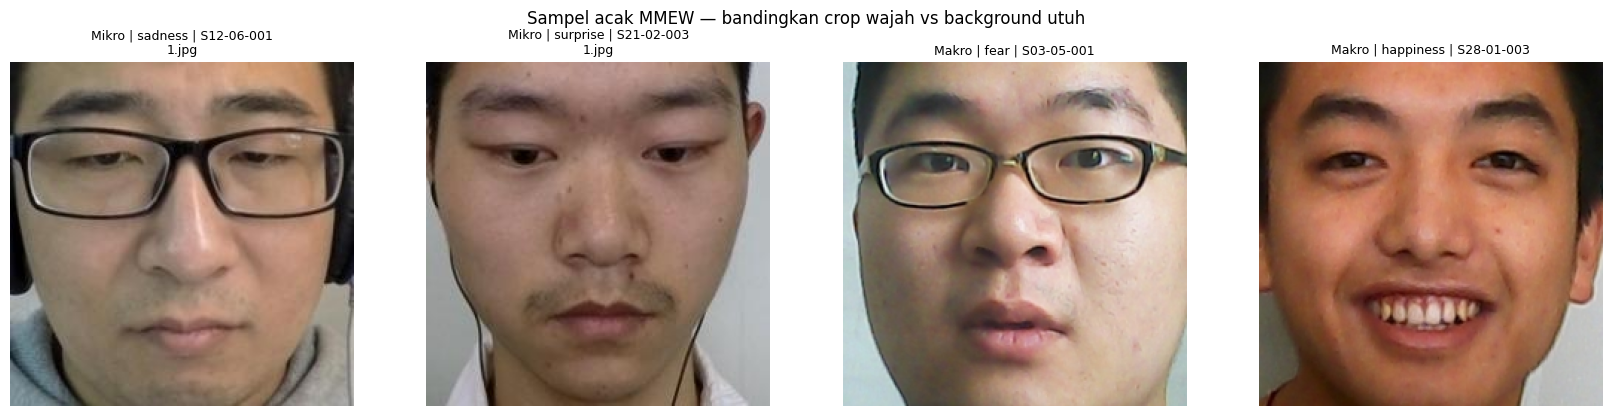

# Komentar visual: jika hanya wajah (tanpa ruang/objek belakang), crop setara SMIC.
# Jika bahu, dinding, atau ruangan terlihat, landmark MediaPipe perlu face-crop dulu.


In [4]:
# =============================================================================
# 4. INSPEKSI RESOLUSI DAN PLOT SAMPEL ACAK
# =============================================================================
def read_bgr(path: Path):
    image = cv2.imread(str(path))
    if image is None:
        raise RuntimeError(f'Gagal membaca gambar: {path}')
    return image


def first_frame_of_clip(clip_dir: Path) -> Path:
    frames = [
        p for p in list_visible(clip_dir)
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    def sort_key(path: Path):
        return int(path.stem) if path.stem.isdigit() else 10**9

    frames.sort(key=sort_key)
    if not frames:
        raise FileNotFoundError(f'Tidak ada frame di {clip_dir}')
    return frames[0]


def summarize_shapes(paths, label: str, max_files: int | None = None):
    shapes = Counter()
    scanned = 0
    for path in paths:
        image = cv2.imread(str(path))
        if image is None:
            continue
        shapes[tuple(image.shape)] += 1
        scanned += 1
        if max_files is not None and scanned >= max_files:
            break
    print(f'{label}: {scanned} file dipindai')
    for shape, count in shapes.most_common():
        if len(shape) == 3:
            h, w, c = shape
            print(f'  {h} x {w} x {c}  →  {count} file')
        else:
            print(f'  {shape}  →  {count} file')
    return shapes


print('=' * 80)
print('SURVEI RESOLUSI')
print('=' * 80)

micro_first_frames = []
if not micro_df.empty:
    micro_first_frames = [first_frame_of_clip(Path(p)) for p in micro_df['sample_path']]
    summarize_shapes(micro_first_frames, 'Mikro (frame pertama tiap klip)')

if not macro_df.empty:
    summarize_shapes((Path(p) for p in macro_df['sample_path']), 'Makro (seluruh still image)')

print()
print('# Komentar analisis: mayoritas 231 x 231 x 3 — wajah sudah di-crop, bukan full-scene.')
print('# Catatan: beberapa still makro bisa sedikit berbeda (mis. 227/230 x 231).')

random.seed(42)
preview_items = []

if not micro_df.empty:
    for _, row in micro_df.sample(n=min(2, len(micro_df)), random_state=42).iterrows():
        frame_path = first_frame_of_clip(Path(row['sample_path']))
        preview_items.append((
            f"Mikro | {row['emotion_label']} | {row['clip_id']}\n{frame_path.name}",
            frame_path,
        ))

if not macro_df.empty:
    for _, row in macro_df.sample(n=min(2, len(macro_df)), random_state=42).iterrows():
        preview_items.append((
            f"Makro | {row['emotion_label']} | {row['clip_id']}",
            Path(row['sample_path']),
        ))

print('\n' + '=' * 80)
print('DETAIL SAMPEL YANG DITAMPILKAN')
print('=' * 80)
for title, path in preview_items:
    image = read_bgr(path)
    h, w, c = image.shape
    print(f'{title}')
    print(f'  path     : {path}')
    print(f'  dimensi  : {h} x {w} x {c}  (tinggi x lebar x channel)')
    print(f'  dtype    : {image.dtype} | min={image.min()} max={image.max()}')
    print()

n_preview = len(preview_items)
fig, axes = plt.subplots(1, n_preview, figsize=(4.2 * n_preview, 4.2))
if n_preview == 1:
    axes = [axes]

for ax, (title, path) in zip(axes, preview_items):
    # OpenCV menyimpan BGR; matplotlib mengharapkan RGB. Tanpa konversi, wajah tampak kebiruan.
    rgb = cv2.cvtColor(read_bgr(path), cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f'{rgb.shape[0]} x {rgb.shape[1]} x {rgb.shape[2]}')
    ax.axis('off')

fig.suptitle('Sampel acak MMEW — bandingkan crop wajah vs background utuh', fontsize=12)
fig.tight_layout()
plt.show()

print('# Komentar visual: jika hanya wajah (tanpa ruang/objek belakang), crop setara SMIC.')
print('# Jika bahu, dinding, atau ruangan terlihat, landmark MediaPipe perlu face-crop dulu.')


## 5. Distribusi Kelas Emosi

Hitung jumlah sampel per emosi, tampilkan sebagai DataFrame, lalu bar chart. Partisi mikro dan makro dipisah karena unit sampelnya berbeda (sekuens vs still).

DISTRIBUSI KELAS

Mikro — jumlah sekuens per emosi:


,emotion_label,n_sampel,n_subjek,persen
0,surprise,89,26,29.67
1,disgust,72,17,24.00
2,others,66,25,22.00
3,happiness,36,17,12.00
4,fear,16,10,5.33
5,sadness,13,9,4.33
6,anger,8,5,2.67



Makro — jumlah still image per emosi:


,emotion_label,n_sampel,n_subjek,persen
0,anger,150,30,16.67
1,disgust,150,30,16.67
2,fear,150,30,16.67
3,happiness,150,30,16.67
4,sadness,150,30,16.67
5,surprise,150,30,16.67


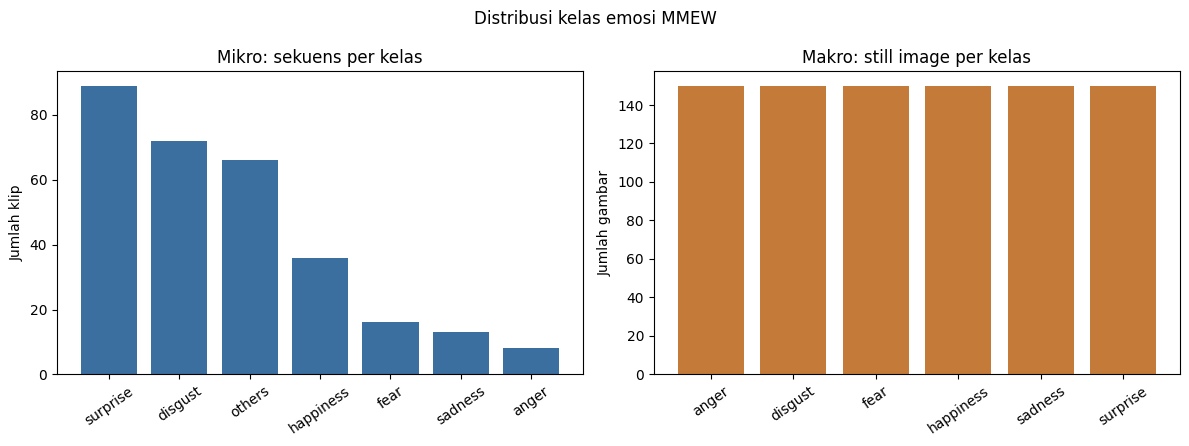


# Komentar analisis distribusi:
# - Mikro TIDAK seimbang: surprise/disgust/others jauh lebih banyak dari anger/sadness/fear.
# - Makro terlihat merata (5 gambar x 6 emosi x 30 subjek = 900).
# - Pre-training ST-GCN sebaiknya memakai Micro_Expression (ada sekuens temporal).
# - Kelas others di mikro tidak punya padanan makro; pertimbangkan apakah ikut dilatih.

RINGKASAN TEMUAN (bahasa Indonesia)
1. Hierarki: Mikro = kelas→klip→frame; Makro = subjek→kelas→gambar tunggal.
2. Format   : 100% .jpg. Bukan video .mp4/.avi.
3. Mikro    : 300 sekuens, 30 subjek, rata-rata 38.0 frame/klip.
4. Makro    : 900 still image dari 30 subjek.
5. Resolusi : dominan 231 x 231 x 3; wajah sudah di-crop (mirip SMIC cropped).
6. Implikasi: pre-training ST-GCN = partisi mikro; makro tidak punya sumbu waktu.


In [5]:
# =============================================================================
# 5. DISTRIBUSI KELAS DAN RINGKASAN EDA
# =============================================================================
def class_table(df: pd.DataFrame, title: str) -> pd.DataFrame:
    table = (
        df.groupby('emotion_label', dropna=False)
        .agg(n_sampel=('clip_id', 'count'), n_subjek=('subject_id', 'nunique'))
        .sort_values('n_sampel', ascending=False)
        .reset_index()
    )
    table['persen'] = (table['n_sampel'] / table['n_sampel'].sum() * 100).round(2)
    print(title)
    display(table)
    return table


print('=' * 80)
print('DISTRIBUSI KELAS')
print('=' * 80)

micro_class = class_table(micro_df, '\nMikro — jumlah sekuens per emosi:') if not micro_df.empty else pd.DataFrame()
macro_class = class_table(macro_df, '\nMakro — jumlah still image per emosi:') if not macro_df.empty else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

if not micro_class.empty:
    axes[0].bar(micro_class['emotion_label'], micro_class['n_sampel'], color='#3b6fa0')
    axes[0].set_title('Mikro: sekuens per kelas')
    axes[0].set_ylabel('Jumlah klip')
    axes[0].tick_params(axis='x', rotation=35)
else:
    axes[0].set_visible(False)

if not macro_class.empty:
    axes[1].bar(macro_class['emotion_label'], macro_class['n_sampel'], color='#c47b3a')
    axes[1].set_title('Makro: still image per kelas')
    axes[1].set_ylabel('Jumlah gambar')
    axes[1].tick_params(axis='x', rotation=35)
else:
    axes[1].set_visible(False)

fig.suptitle('Distribusi kelas emosi MMEW')
fig.tight_layout()
plt.show()

print('\n# Komentar analisis distribusi:')
print('# - Mikro TIDAK seimbang: surprise/disgust/others jauh lebih banyak dari anger/sadness/fear.')
print('# - Makro terlihat merata (5 gambar x 6 emosi x 30 subjek = 900).')
print('# - Pre-training ST-GCN sebaiknya memakai Micro_Expression (ada sekuens temporal).')
print('# - Kelas others di mikro tidak punya padanan makro; pertimbangkan apakah ikut dilatih.')

print('\n' + '=' * 80)
print('RINGKASAN TEMUAN (bahasa Indonesia)')
print('=' * 80)
print('1. Hierarki: Mikro = kelas→klip→frame; Makro = subjek→kelas→gambar tunggal.')
print('2. Format   : 100% .jpg. Bukan video .mp4/.avi.')
if not micro_df.empty:
    print(
        f"3. Mikro    : {len(micro_df)} sekuens, "
        f"{micro_df['subject_id'].nunique()} subjek, "
        f"rata-rata {micro_df['n_frames'].mean():.1f} frame/klip."
    )
if not macro_df.empty:
    print(f'4. Makro    : {len(macro_df)} still image dari {macro_df["subject_id"].nunique()} subjek.')
print('5. Resolusi : dominan 231 x 231 x 3; wajah sudah di-crop (mirip SMIC cropped).')
print('6. Implikasi: pre-training ST-GCN = partisi mikro; makro tidak punya sumbu waktu.')